# Análisis exploratorio y agrupamiento del dataset Supermarket Sales

Este notebook realiza:
- Carga del dataset desde la URL proporcionada
- Análisis univariado (distribuciones, estadísticos)
- Análisis bivariado (correlaciones, scatterplots, boxplots)
- Análisis con 3 variables (pairplots y 3D scatter)
- Normalización de la columna de ingresos y repetición de los análisis enfocados en esa columna
- Búsqueda de agrupaciones (KMeans) y visualización (PCA)

Todo el notebook está en español en comentarios y celdas explicativas.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

sns.set(style='whitegrid')
%matplotlib inline

In [2]:
# Cargar dataset desde la URL proporcionada
url = "https://raw.githubusercontent.com/restevesd/fuentes/main/supermarket_sales.csv"
df = pd.read_csv(url)
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (1000, 17)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


## Inspección rápida: tipos de columna y valores faltantes

In [3]:
df.info()
print('\nValores faltantes por columna:')
print(df.isnull().sum())

print('\nEstadísticos generales (numéricos):')
display(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
count,1000,1000,1000,1000,1000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000,1000,1000.00000,1000.000000,1000.000000,1000.00000
unique,1000,3,3,2,2,6,NaN,NaN,NaN,NaN,89,506,3,NaN,NaN,NaN,NaN
top,750-67-8428,A,Yangon,Member,Female,Fashion accessories,NaN,NaN,NaN,NaN,2/7/2019,19:48,Ewallet,NaN,NaN,NaN,NaN
freq,1,340,340,501,501,178,NaN,NaN,NaN,NaN,20,7,345,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,55.672130,5.510000,15.379369,322.966749,NaN,NaN,NaN,307.58738,4.761905,15.379369,6.97270
std,NaN,NaN,NaN,NaN,NaN,NaN,26.494628,2.923431,11.708825,245.885335,NaN,NaN,NaN,234.17651,0.000000,11.708825,1.71858
min,NaN,NaN,NaN,NaN,NaN,NaN,10.080000,1.000000,0.508500,10.678500,NaN,NaN,NaN,10.17000,4.761905,0.508500,4.00000
25%,NaN,NaN,NaN,NaN,NaN,NaN,32.875000,3.000000,5.924875,124.422375,NaN,NaN,NaN,118.49750,4.761905,5.924875,5.50000
50%,NaN,NaN,NaN,NaN,NaN,NaN,55.230000,5.000000,12.088000,253.848000,NaN,NaN,NaN,241.76000,4.761905,12.088000,7.00000
75%,NaN,NaN,NaN,NaN,NaN,NaN,77.935000,8.000000,22.445250,471.350250,NaN,NaN,NaN,448.90500,4.761905,22.445250,8.50000


## Identificar columna de ingresos

Hay varias posibilidades comunes: 'gross income', 'Gross income', 'gross_income', 'Total'.
Seleccionaremos la columna disponible con preferencia por 'gross income' y si no existe usaremos 'Total'.

In [4]:
# Detectar columna de ingresos
possible_income_cols = ['Total','gross income', 'Gross income', 'gross_income', 'grossincome',  'total']
income_col = None
for c in possible_income_cols:
    if c in df.columns:
        income_col = c
        break
if income_col is None:
    # Si no se encuentra, buscar heurísticamente por columna que contenga 'income' o 'total'
    for c in df.columns:
        if 'income' in c.lower() or 'total' in c.lower():
            income_col = c
            break

print('Columna escogida como ingresos:', income_col)
df[income_col].describe() if income_col else None

Columna escogida como ingresos: Total


count    1000.000000
mean      322.966749
std       245.885335
min        10.678500
25%       124.422375
50%       253.848000
75%       471.350250
max      1042.650000
Name: Total, dtype: float64

In [5]:
df['Total'].describe()

count    1000.000000
mean      322.966749
std       245.885335
min        10.678500
25%       124.422375
50%       253.848000
75%       471.350250
max      1042.650000
Name: Total, dtype: float64

## Análisis Univariado
- Para variables numéricas: histograma, boxplot, estadísticos.
- Para variables categóricas: conteos y proporciones.

Numéricas: ['Unit price', 'Quantity', 'Tax 5%', 'Total', 'cogs', 'gross margin percentage', 'gross income', 'Rating']
Categóricas (ejemplos): ['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Date', 'Time', 'Payment']


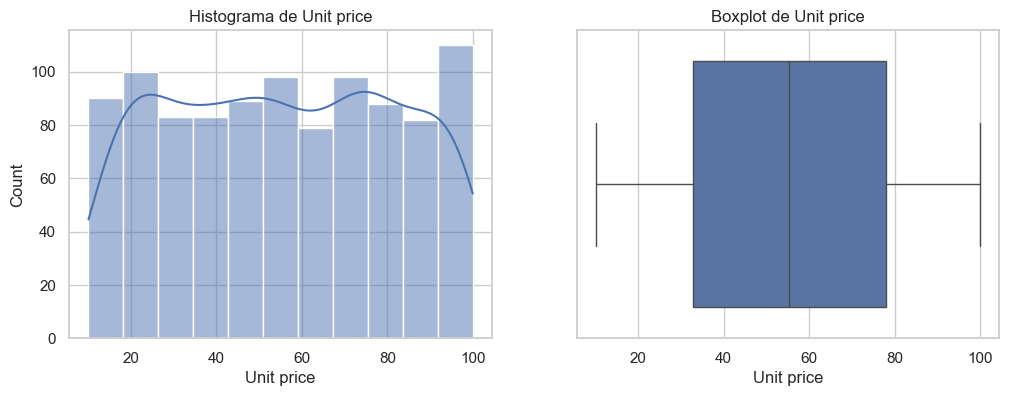

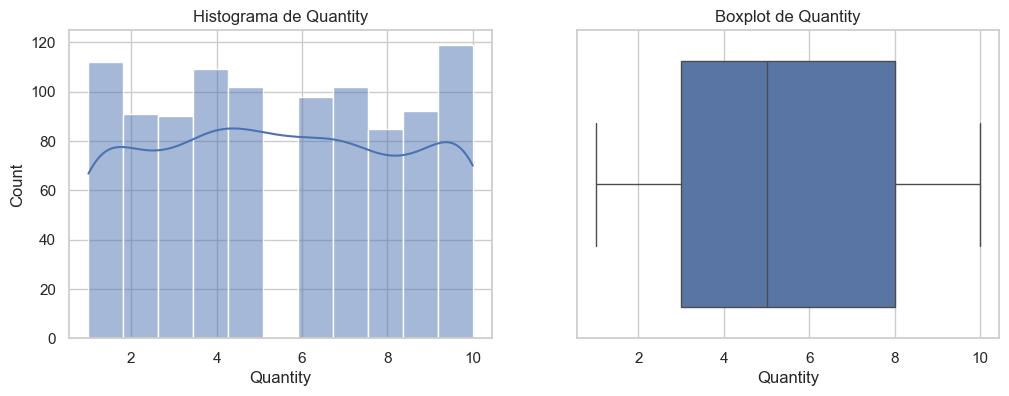

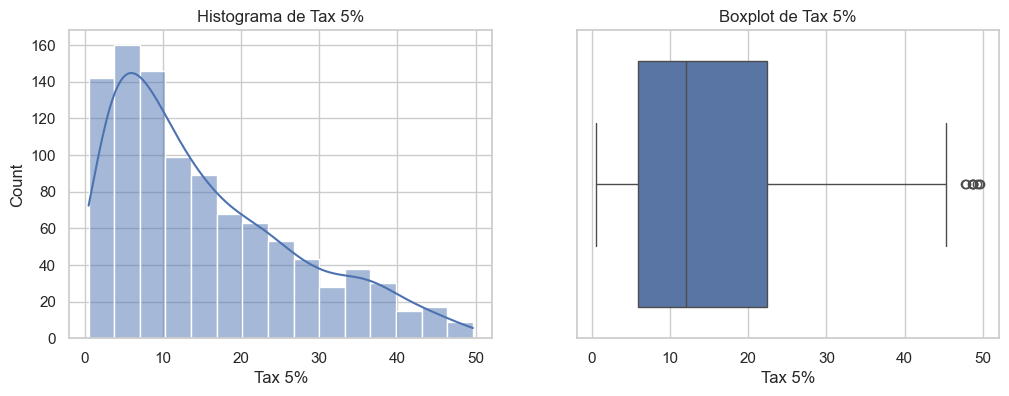

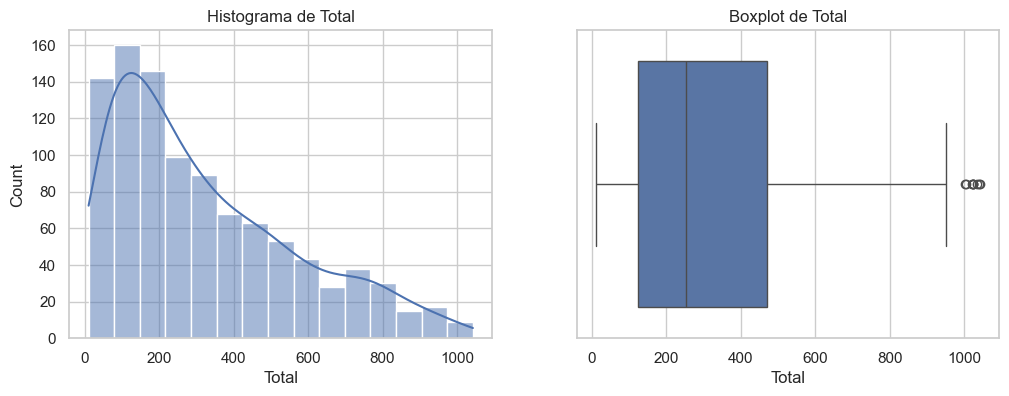

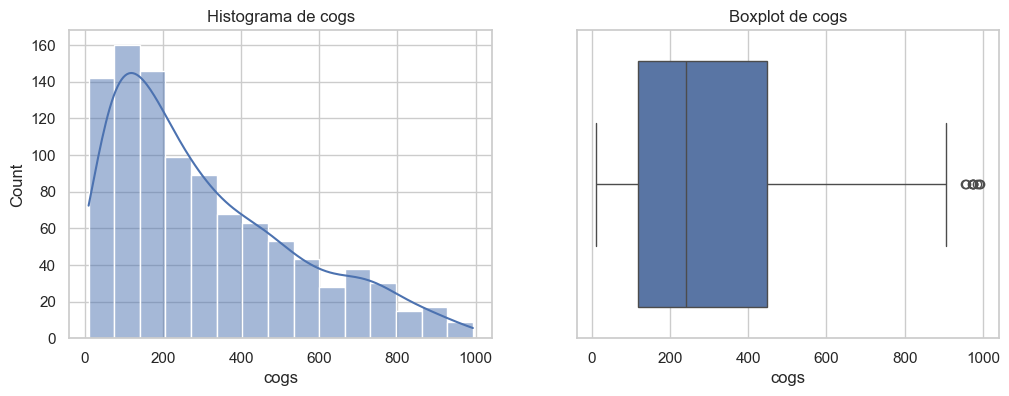

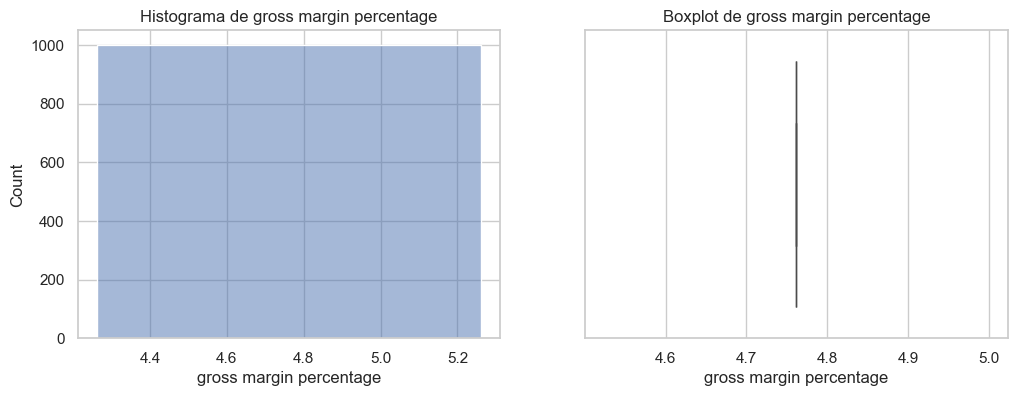

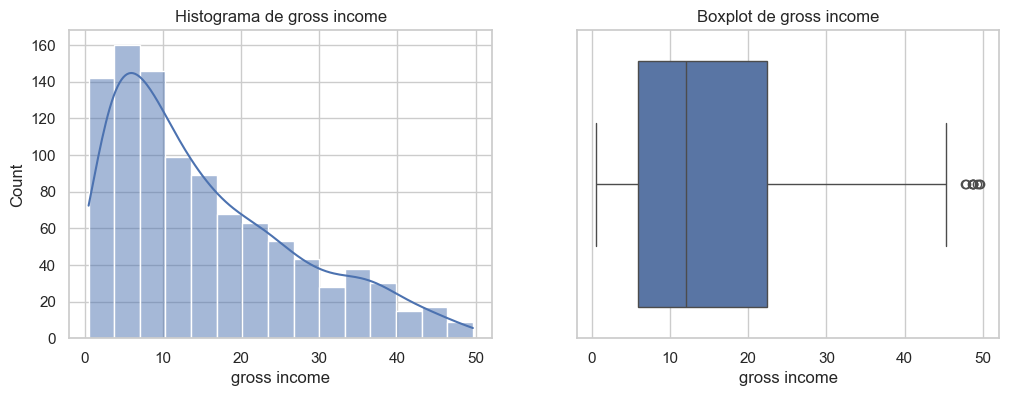

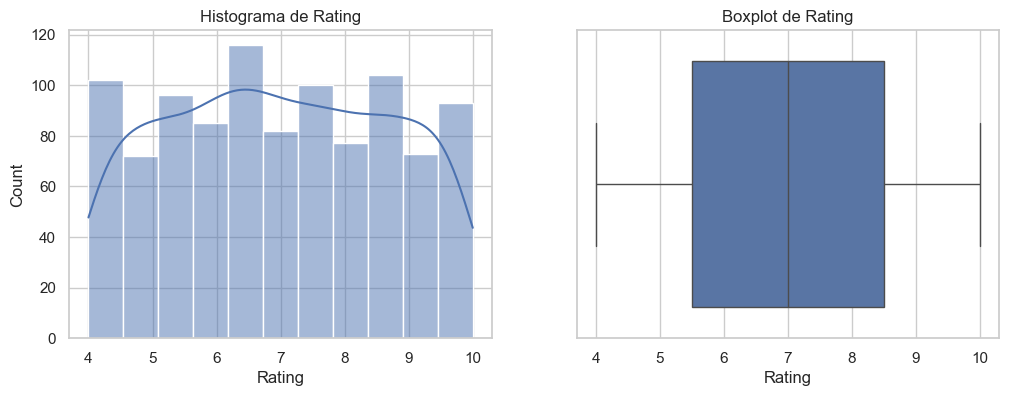


Conteos de Invoice ID


Invoice ID
750-67-8428    1
642-61-4706    1
816-72-8853    1
491-38-3499    1
322-02-2271    1
842-29-4695    1
725-67-2480    1
641-51-2661    1
714-02-3114    1
518-17-2983    1
Name: count, dtype: int64


Conteos de Branch


Branch
A    340
B    332
C    328
Name: count, dtype: int64


Conteos de City


...

Date
2/7/2019     20
2/15/2019    19
3/14/2019    18
3/2/2019     18
1/8/2019     18
1/26/2019    17
1/25/2019    17
1/23/2019    17
3/5/2019     17
3/19/2019    16
Name: count, dtype: int64


Conteos de Time


Time
19:48    7
14:42    7
17:38    6
17:16    5
11:40    5
13:48    5
19:39    5
19:20    5
17:36    5
13:58    5
Name: count, dtype: int64


Conteos de Payment


Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64

In [6]:
# Variables numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print('Numéricas:', num_cols)
print('Categóricas (ejemplos):', cat_cols[:10])

# Histogramas y boxplots para numéricas
for col in num_cols:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Histograma de {col}')
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col].dropna())
    plt.title(f'Boxplot de {col}')
    plt.show()

# Conteos para categóricas (top 10)
for col in cat_cols:
    print('\nConteos de', col)
    display(df[col].value_counts().head(10))

## Análisis Bivariado
- Matriz de correlación para numéricas
- Scatterplots para pares interesantes
        - Por ejemplo: Unit price vs Quantity, Income vs Quantity, Income vs Unit price
        - Boxplots de ingresos por categorías (p.ej. Product line, Gender, Branch)

In [ ]:
# Matriz de correlación
plt.figure(figsize=(10,8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación (numéricas)')
plt.show()

# Algunos scatterplots
pair_candidates = []

if 'Unit price' in df.columns and 'Quantity' in df.columns:
    pair_candidates.append(('Unit price','Quantity'))
if income_col:
    # buscar variaciones posibles
    pair_candidates.append((income_col,'Quantity'))
    pair_candidates.append((income_col,'Unit price'))

for x,y in pair_candidates:
    if x in df.columns and y in df.columns:
        plt.figure(figsize=(6,4))
        sns.scatterplot(data=df, x=x, y=y, hue=cat_cols[0] if cat_cols else None, alpha=0.7)
        plt.title(f'{y} vs {x}')
        plt.show()

# Boxplot de ingresos por categorías clave (si existen)
categorical_for_income = [c for c in ['Product line','Gender','Branch','Customer type','Payment'] if c in df.columns]
for cat in categorical_for_income:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=cat, y=income_col, data=df)
    plt.title(f'{income_col} por {cat}')
    plt.xticks(rotation=45)
    plt.show()

## Análisis con 3 variables
- Pairplot (hasta un subconjunto razonable)
- Visualización 3D usando tres variables numéricas relevantes

In [ ]:
# Seleccionar hasta 5 variables para pairplot (incluyendo income si existe)
vars_for_pair = []
candidates = ['Unit price','Quantity','Rating', income_col, 'cogs']
for c in candidates:
    if c and c in df.columns:
        vars_for_pair.append(c)
    
vars_for_pair = vars_for_pair[:5]
print('Variables para pairplot:', vars_for_pair)
if len(vars_for_pair) >= 2:
    sns.pairplot(df[vars_for_pair].dropna(), diag_kind='kde', corner=False)
    plt.suptitle('Pairplot de variables seleccionadas', y=1.02)
    plt.show()

# 3D scatter si hay al menos 3 variables numéricas
three_num = [c for c in ['Unit price','Quantity', income_col, 'Rating', 'cogs'] if c in df.columns][:3]
if len(three_num) == 3:
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(df[three_num[0]], df[three_num[1]], df[three_num[2]], c='blue', alpha=0.6)
    ax.set_xlabel(three_num[0])
    ax.set_ylabel(three_num[1])
    ax.set_zlabel(three_num[2])
    plt.title('3D scatter de 3 variables')
    plt.show()
else:
    print('No hay suficientes variables numéricas distintas para 3D scatter.')

## Normalización de la columna de ingresos
Vamos a normalizar usando MinMaxScaler (escala 0-1). Agregaremos una nueva columna con sufijo '_norm'.

In [ ]:
from sklearn.exceptions import NotFittedError

if income_col is None:
    raise ValueError('No se pudo identificar la columna de ingresos. Revise el dataset.')

norm_col = income_col + '_norm'
scaler = MinMaxScaler()
df[norm_col] = scaler.fit_transform(df[[income_col]].fillna(df[income_col].median()))
print(df[[income_col, norm_col]].head())
print('\nEstadísticas columna normalizada:')
display(df[norm_col].describe())

### Repetir análisis centrado en la columna de ingresos normalizada
- Distribución univariada de la columna normalizada
- Correlaciones y scatterplots con la columna normalizada

In [ ]:
# Univariado de la columna normalizada
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
sns.histplot(df[norm_col].dropna(), kde=True)
plt.title(f'Histograma de {norm_col}')
plt.subplot(1,2,2)
sns.boxplot(x=df[norm_col].dropna())
plt.title(f'Boxplot de {norm_col}')
plt.show()

# Correlación de la columna normalizada con otras numéricas
corr_with_norm = df[num_cols + [norm_col]].corr()[norm_col].sort_values(ascending=False)
print('Correlaciones con', norm_col)
display(corr_with_norm)

# Scatterplots relevantes con la columna normalizada
for col in ['Quantity','Unit price','Rating']:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[norm_col], y=df[col], alpha=0.6)
        plt.title(f'{col} vs {norm_col}')
        plt.show()

## Búsqueda de agrupaciones (clustering)
Usaremos características numéricas relevantes (incluyendo la columna de ingresos normalizada) y aplicaremos KMeans.

Pasos:

- Selección de variables numéricas y escalado
- Método del codo + silhouette para sugerir número de clusters
- KMeans y visualización en 2D con PCA

In [ ]:
# Selección de columnas numéricas útiles para clustering
features = [c for c in num_cols if c not in ['Invoice ID']]
if norm_col not in features:
    features.append(norm_col)

# Nos quedamos con un subconjunto razonable
features = [f for f in features if df[f].nunique() > 1][:6]
print('Features usadas para clustering:', features)

# Preparar datos: rellenar NA y estandarizar
X = df[features].fillna(df[features].median())
X_scaled = StandardScaler().fit_transform(X)

# Método del codo y silhouette
inertia = []
sil_scores = []
K_range = range(2,9)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(list(K_range), inertia, '-o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Método del codo')
plt.subplot(1,2,2)
plt.plot(list(K_range), sil_scores, '-o')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette')
plt.show()

# Elegir k (podemos basarnos en la gráfica; aquí usamos el k que maximiza silhouette)
best_k = K_range[int(np.argmax(sil_scores))]
print('k sugerido por silhouette:', best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters
print('\nDistribución de clusters:')
display(df['cluster'].value_counts().sort_index())

# Visualizar clusters en 2D usando PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='tab10', alpha=0.7)
plt.title('Clusters visualizados en 2D por PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='cluster')
plt.show()

# Resumen por cluster
display(df.groupby('cluster')[features].mean())

## Conclusiones rápidas y recomendaciones
- Se inspeccionaron distribuciones univariadas y se identificaron valores atípicos en algunas variables numéricas (ver boxplots).
- Las correlaciones muestran relaciones esperadas (por ejemplo, Total/gross income con Quantity y Unit price).
- Tras normalizar la columna de ingresos (MinMax 0-1), se repitieron los análisis y se observó cómo cambia la influencia relativa al combinarla con otras variables.
- El clustering con KMeans produjo una partición útil en k sugerido por silhouette; examinar los promedios por cluster ayuda a interpretar grupos (p. ej. cluster de transacciones de alto ingreso, cluster de baja cantidad, etc.).

Siguientes pasos sugeridos:
- Ajustar features para clustering (incluir variables categóricas como dummies si se desea)
- Probar DBSCAN o clustering jerárquico para detectar outliers/grupos de forma diferente
- Construir perfiles de cliente/product line por cluster para análisis de negocio


In [ ]:
# Guardar una versión del dataframe con la columna normalizada y cluster
df.to_csv('supermarket_sales_processed.csv', index=False)
print('Archivo supermarket_sales_processed.csv guardado en el directorio de trabajo.')

In [20]:
df.columns
filter_Col= ['Invoice ID',  'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity','Total', 'Payment', 'Rating']
df_n= df[filter_Col]
df_n.head()
len(df_n['Invoice ID'].unique())
filter_Col= [ 'Customer type', 'Gender', 'Product line',  'Quantity','Total', 'Payment', 'Rating']
df_n= df[filter_Col]
df_n.head()

,Customer type,Gender,Product line,Quantity,Total,Payment,Rating
0,Member,Female,Health and beauty,7,548.9715,Ewallet,9.1
1,Normal,Female,Electronic accessories,5,80.2200,Cash,9.6
2,Normal,Male,Home and lifestyle,7,340.5255,Credit card,7.4
3,Member,Male,Health and beauty,8,489.0480,Ewallet,8.4
4,Normal,Male,Sports and travel,7,634.3785,Ewallet,5.3
